# DL-Quantum

Previsione delle traiettorie di un sistema quantistico a 10 qubit (55 osservabili: 10 magnetizzazioni e 45 correlazioni) con una rete ricorrente e un Transformer causale, entrambi costruiti a partire dai soli layer primitivi di Keras, senza modelli pre-addestrati.

Il problema che governa quasi tutte le scelte del progetto è l'**exposure bias**: un modello addestrato a prevedere un solo passo in avanti riceve sempre valori veri in ingresso, mentre nel rollout autoregressivo deve consumare le proprie previsioni, e l'errore si accumula. Per attenuarlo ho scritto un unico training loop che attraversa tre regimi:

1. **teacher forcing** — il modello impara la dinamica a un passo sulla finestra di valori osservati;
2. **masked modeling** — una parte degli istanti in ingresso viene azzerata e pesata di più nella loss, così il modello impara a ricostruire il segnale da un contesto incompleto;
3. **scheduled sampling** — una frazione crescente degli ingressi viene sostituita dalle previsioni del modello, avvicinando l'addestramento alle condizioni del rollout.

Le celle seguono l'ordine della pipeline: preparazione dei dati con partizionamento per traiettoria, addestramento dimostrativo, sweep degli iperparametri in 5-fold cross-validation con ablation dello schedule, inferenza sul test set, controlli di riproducibilità ed esportazione dei risultati.

Il metro di giudizio non è l'errore in sé ma il confronto con i predittori banali (persistence, drift, media del contesto, media del training): lo skill score dice se i modelli aggiungono qualcosa rispetto a chi non impara nulla.

## Cella 1 — Montaggio di Google Drive

Collego Google Drive per accedere ai moduli sorgente in `src/` e al dataset delle traiettorie.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cella 2 — Ambiente di lavoro locale e trasferimento dei dati

Copio il dataset (circa 442 MB) e i sorgenti nello spazio locale della macchina virtuale invece di leggerli da Drive: l'accesso a Drive è mediato dalla rete e durante l'addestramento diventa il collo di bottiglia principale. La cella svuota `src/`, `tests/` e `artifacts/` prima di ricopiare, così ogni esecuzione riparte da uno stato pulito: `copytree` fonde le cartelle invece di sostituirle, quindi senza questa pulizia un file rimosso dal progetto o gli artefatti di uno sweep precedente resterebbero nella cartella di lavoro. Il dataset non viene ricopiato se è già presente. Verifica infine che tutti i moduli attesi ci siano, così un file dimenticato si manifesta subito e non a metà dello sweep.

In [2]:
#Importo le librerie necessarie e creo una cartella di lavoro locale per ottimizzare le operazioni
#Leggere il dataset da 442 MB direttamente da Drive rallenterebbe troppo l'esecuzione
import os, glob, shutil

WORK = '/content/work'
os.makedirs(WORK, exist_ok=True)

#Con RIPARTI_DA_ZERO la cella svuota src/ e artifacts/ prima di ricopiare i sorgenti
#Serve perche' copytree(dirs_exist_ok=True) fonde le cartelle invece di sostituirle:
#senza questa pulizia un file rimosso dal progetto, o gli artefatti di uno sweep precedente, sopravvivrebbero nella working directory e finirebbero nell'archivio finale
#Il CSV non viene toccato: ricopiarlo costerebbe diversi minuti
RIPARTI_DA_ZERO = True
if RIPARTI_DA_ZERO:
    for sub in ('src', 'tests', 'artifacts'):
        shutil.rmtree(os.path.join(WORK, sub), ignore_errors=True)
    print('working directory ripulita (src/, tests/, artifacts/)')

#Cerco la mia cartella src/ su Drive: uso la presenza di 'baselines.py' come discriminante
#Se su Drive ci sono piu' copie del progetto scelgo la piu' recente,altrimenti l'ordine alfabetico potrebbe far vincere una versione vecchia.
candidati = [p for p in glob.glob('/content/drive/My Drive/**/src', recursive=True)
             if os.path.isfile(os.path.join(p, 'baselines.py'))]
assert candidati, "Nessuna cartella src/ completa trovata su Drive."

SRC = max(candidati, key=lambda p: os.path.getmtime(os.path.join(p, 'baselines.py')))
if len(candidati) > 1:
    print(f"trovate {len(candidati)} copie di src/ su Drive; uso la piu' recente:")
print('src/ ->', SRC)
shutil.copytree(SRC, os.path.join(WORK, 'src'), dirs_exist_ok=True)

#Verifico che tutti i moduli attesi siano presenti: un file dimenticato si manifesta qui e non a meta' dello sweep
ATTESI = ['data_preprocessing.py', 'models.py', 'training.py', 'baselines.py',
          'experiments.py', 'make_report_macros.py', 'dump_report_numbers.py',
          'run_step1_preprocessing.py', 'run_step2_demo.py', 'run_step3_experiments.py',
          'run_inference.py', 'analyze_phase_decay.py']
mancanti = [f for f in ATTESI if not os.path.isfile(os.path.join(WORK, 'src', f))]
assert not mancanti, f"File mancanti in src/: {mancanti}"

#Importo anche la cartella con i test
tst = os.path.join(os.path.dirname(SRC), 'tests')
if os.path.isdir(tst):
    shutil.copytree(tst, os.path.join(WORK, 'tests'), dirs_exist_ok=True)

#Copio il dataset di 442 MB localmente
#Leggerlo direttamente da Drive durante il training causerebbe colli di bottiglia
target = os.path.join(WORK, 'trajectories.csv')
if os.path.exists(target):
    print(f"CSV gia' presente ({os.path.getsize(target)/1024**3:.2f} GB)")
else:
    csv_hits = sorted(glob.glob('/content/drive/My Drive/**/trajectories.csv', recursive=True))
    assert csv_hits, "trajectories.csv non trovato su Drive."
    print("CSV trovato")
    shutil.copy(csv_hits[0], target)

#Mi posiziono nella working directory locale e ne verifico il contenuto
os.chdir(WORK)
print('\ncontenuto di', WORK)
for f in sorted(os.listdir(WORK)):
    full = os.path.join(WORK, f)
    print(f"  {f}" + (f"  ({os.path.getsize(full)/1024**2:.0f} MB)" if os.path.isfile(full) else "/"))

working directory ripulita (src/, tests/, artifacts/)
src/ -> /content/drive/My Drive/DL_Quantum/src
CSV trovato

contenuto di /content/work
  src/
  tests/
  trajectories.csv  (442 MB)


## Cella 3 — Verifica delle dipendenze

Controllo la presenza di TensorFlow, NumPy, pandas e matplotlib e l'aggancio all'acceleratore.

In [3]:
import subprocess, sys

#Installo le librerie fondamentali se non sono già presenti nell'ambiente
for pkg in ['tensorflow', 'numpy', 'pandas', 'matplotlib']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

#Verifico il corretto caricamento di TensorFlow e l'aggancio alla GPU
#Lo sweep completo su CPU richiederebbe ore: se la GPU non risulta disponibile conviene fermarsi qui
import tensorflow as tf
print('TensorFlow', tf.__version__)
print('GPU disponibili:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0
GPU disponibili: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cella 4 — Step 1: preprocessing, controlli di integrità ed EDA

Il primo modulo prepara i dati e ne verifica la consistenza prima di qualunque addestramento:

* **Controlli di integrità** — geometria del tensore, assenza di NaN e infiniti, uniformità del passo temporale, limiti fisici $|m|,|c|\le 1$ delle osservabili. Se un controllo fallisce l'esecuzione si ferma: un dato sbagliato che passa di qui si ritrova in ogni numero prodotto dopo.
* **Partizionamento per traiettoria** — train, validation e test contengono simulazioni diverse. Suddividere le singole finestre invece delle traiettorie farebbe finire in insiemi diversi spezzoni della stessa dinamica, e la stima dell'errore risulterebbe ottimistica.
* **Standardizzazione z-score per feature** — media e deviazione stimate solo sul training. La loss è quadratica: se le deviazioni standard delle osservabili differiscono di un fattore $r$, i contributi alla loss differiscono di $r^2$, e le variabili più ampie determinerebbero da sole la direzione del gradiente.
* **Baseline banali** — persistence, drift, media del contesto e media del training, calcolate già qui: sono il riferimento rispetto a cui gli errori dei modelli diventano interpretabili.

Vengono inoltre salvate le figure esplorative a 300 dpi e la cache dei tensori preparati.

In [4]:
import subprocess

#Avvio lo script che ho scritto per il preprocessing
#Applica lo Z-Score scaler solo sul train set, divide le fold e calcola le Trivial Baselines
r = subprocess.run(['python3', 'src/run_step1_preprocessing.py',
                    '--csv', 'trajectories.csv', '--out', 'artifacts',
                    '--windows', '50,100', '--horizon', '200', '--origins', '0,250,500'],
                   cwd='/content/work')
print('\nSTEP 1 completato' if r.returncode == 0 else f'\nSTEP 1 FALLITO (exit {r.returncode})')


STEP 1 completato


## Cella 5 — Step 2: prova del training loop multi-regime

Una run dimostrativa su una singola finestra ($L=50$), non un esperimento: serve a verificare che il ciclo unificato converga e a produrre le figure qualitative dei tre regimi e del rollout. Il loop è scritto con `tf.GradientTape` e alterna teacher forcing, masked modeling e scheduled sampling secondo lo schedule passato da riga di comando, senza mai ricostruire il modello. Le conclusioni quantitative vengono invece dallo Step 3, che ripete tutto in cross-validation.

In [5]:
import subprocess

#Faccio una run veloce per testare il mio Multi-Regime Training Loop
#Uso uno schedule bilanciato (6 epoche TF, 6 epoche MM, 3 epoche SS) per validare la pipeline
r = subprocess.run(['python3', 'src/run_step2_demo.py',
                    '--csv', 'trajectories.csv', '--out', 'artifacts',
                    '--window', '50', '--horizon', '200', '--origins', '0,250,500',
                    '--schedule', '6,6,3'],
                   cwd='/content/work')
print('\nSTEP 2 completato' if r.returncode == 0 else f'\nSTEP 2 FALLITO (exit {r.returncode})')


STEP 2 completato


## Cella 6 — Step 3: sweep, cross-validation e ablation

È la parte computazionalmente pesante, circa 60-90 minuti su GPU T4. Ogni configurazione di iperparametri viene valutata in 5-fold cross-validation sulle traiettorie e su due finestre di contesto ($L=50$ e $L=100$): quattro configurazioni per famiglia, due finestre, cinque fold, cioè 80 addestramenti, più i quattro riaddestramenti finali delle configurazioni selezionate.

Il flag `--ablation` aggiunge il confronto fra le varianti dello schedule a parità di budget: ogni variante consuma le stesse 15 epoche, redistribuite fra i regimi, altrimenti la variante più ricca vincerebbe solo perché si addestra di più. È una verifica empirica, non una dimostrazione: quello che si misura è se l'aggiunta di un regime sposta l'errore più di quanto oscilli fra i fold, e la risposta va letta sugli intervalli di confidenza. L'ablation non dice invece nulla sull'ordine dei regimi né sulla ripartizione delle epoche fra loro, che restano fissati.

In [6]:
import subprocess

#Avvio l'esperimento principale: 5-Fold Cross Validation per garantire solidità statistica
#Uso il flag --ablation per avviare i test comparativi a parità di epoche
r = subprocess.run(['python3', 'src/run_step3_experiments.py',
                    '--csv', 'trajectories.csv', '--out', 'artifacts/step3',
                    '--windows', '50,100', '--folds', '5', '--schedule', '6,6,3',
                    '--horizon', '200', '--origins', '0,250,500',
                    '--ss-mode', 'true', '--ss-passes', '3',
                    '--ablation'],
                   cwd='/content/work')
print('\nSTEP 3 completato' if r.returncode == 0 else f'\nSTEP 3 FALLITO (exit {r.returncode})')


STEP 3 completato


## Cella 7 — Tabelle dei risultati

Stampo le tabelle prodotte dalla cross-validation. Ogni metrica è riportata come media sui fold con l'intervallo di confidenza al 95%, calcolato con la $t$ di Student a quattro gradi di libertà: con cinque fold la dispersione fra le repliche è dello stesso ordine delle differenze fra configurazioni, e senza intervallo il confronto non sarebbe leggibile.

Le metriche stanno su due piani. Quelle a un passo misurano la dinamica locale; quelle di rollout misurano l'accumulo dell'errore sull'intero orizzonte, che è il compito di interesse. Lo skill score, $1-\text{RMSE}/\text{RMSE}_{\text{migliore baseline}}$, è la sintesi dei due: è positivo solo se il modello batte ogni predittore banale, e quando è negativo significa che sul rollout conviene ancora la baseline.

In [7]:
import os, glob
os.chdir('/content/work')

#Leggo e stampo le tabelle prodotte dallo Step 3: medie sui fold e intervalli di confidenza
for p in sorted(glob.glob('artifacts/step3/table*.csv')):
    print('=' * 78)
    print(p)
    print('=' * 78)
    print(open(p).read())
    print()

artifacts/step3/table1_L100.csv
metric,BASELINE_context_mean,BASELINE_drift,BASELINE_persistence,BASELINE_train_mean,RNN_R1,RNN_R2,RNN_R3,RNN_R4,TRANSFORMER_T1,TRANSFORMER_T2,TRANSFORMER_T3,TRANSFORMER_T4
Next-step RMSE (scaled),0.7770+-0.0065,0.0049+-0.0000*,0.0440+-0.0004,1.0011+-0.0071,0.0631+-0.0015,0.1785+-0.0041,0.0842+-0.0017,0.2002+-0.0042,0.5088+-0.0013,0.5604+-0.0040,0.2215+-0.0174,0.2322+-0.0046
Next-step MAE (scaled),0.5750+-0.0044,0.0025+-0.0000*,0.0345+-0.0003,0.7969+-0.0055,0.0438+-0.0011,0.1313+-0.0034,0.0649+-0.0014,0.1541+-0.0033,0.3988+-0.0022,0.4451+-0.0037,0.1686+-0.0134,0.1752+-0.0038
Rollout RMSE (phys),0.0251+-0.0001*,0.1488+-0.0011,0.0366+-0.0003,0.0270+-0.0001,0.0421+-0.0030,0.0368+-0.0005,0.0438+-0.0022,0.0390+-0.0009,0.0336+-0.0009,0.0343+-0.0019,0.0367+-0.0023,0.0348+-0.0010
Rollout MAE (phys),0.0194+-0.0001*,0.0988+-0.0007,0.0275+-0.0002,0.0212+-0.0001,0.0322+-0.0022,0.0283+-0.0005,0.0339+-0.0015,0.0299+-0.0007,0.0256+-0.0005,0.0261+-0.0011,0.0274+-0.0015,

## Cella 8 — Inferenza sul test set

Carico i pesi dei modelli selezionati e li valuto sul test set. I dati necessari sono già isolati nel pacchetto compresso `test_pack_L*.npz` prodotto dallo Step 3, quindi non serve rileggere il CSV completo e la valutazione parte in pochi secondi. Vengono calcolate sia la previsione a un passo sia il rollout autoregressivo sull'intero orizzonte, accanto alle baseline calcolate sugli stessi dati.

In [8]:
import sys, subprocess

#Finestra temporale da valutare
WINDOW = 50

#Inferenza sul test set a partire dai modelli salvati:
#previsione a un passo, rollout autoregressivo e confronto con le baseline
subprocess.run([sys.executable, 'run_inference.py',
                '--models', '../artifacts/step3/models',
                '--window', str(WINDOW)],
               cwd='/content/work/src')

CompletedProcess(args=['/usr/bin/python3', 'run_inference.py', '--models', '../artifacts/step3/models', '--window', '50'], returncode=0)

### Cella 8-bis — la stessa valutazione, senza subprocess

Stessa inferenza della cella precedente, eseguita direttamente nel notebook invece che come processo esterno: metriche e figure del rollout compaiono qui sotto, così il confronto fra modelli e baseline è leggibile senza aprire i file prodotti.

[inferenza] pacchetto usato: test_pack_L50.npz
test: 60 traiettorie | un passo (1200, 50, 55) | rollout (180, 50, 55) -> (180, 200, 55)
  baseline train_mean     rollout RMSE = 0.02806   NRMSE = 0.599
  baseline context_mean   rollout RMSE = 0.02987   NRMSE = 0.638
  baseline persistence    rollout RMSE = 0.04009   NRMSE = 0.856
  baseline drift          rollout RMSE = 0.13140   NRMSE = 2.807

best_rnn_R2_L50  (34,295 parametri)
  RMSE a un passo (scalato) = 0.1402   MAE = 0.0896
  RMSE di rollout (fisico)  = 0.03764   NRMSE = 0.804   skill = -0.341

best_transformer_T4_L50  (173,559 parametri)
  RMSE a un passo (scalato) = 0.1727   MAE = 0.1293
  RMSE di rollout (fisico)  = 0.03686   NRMSE = 0.787   skill = -0.314


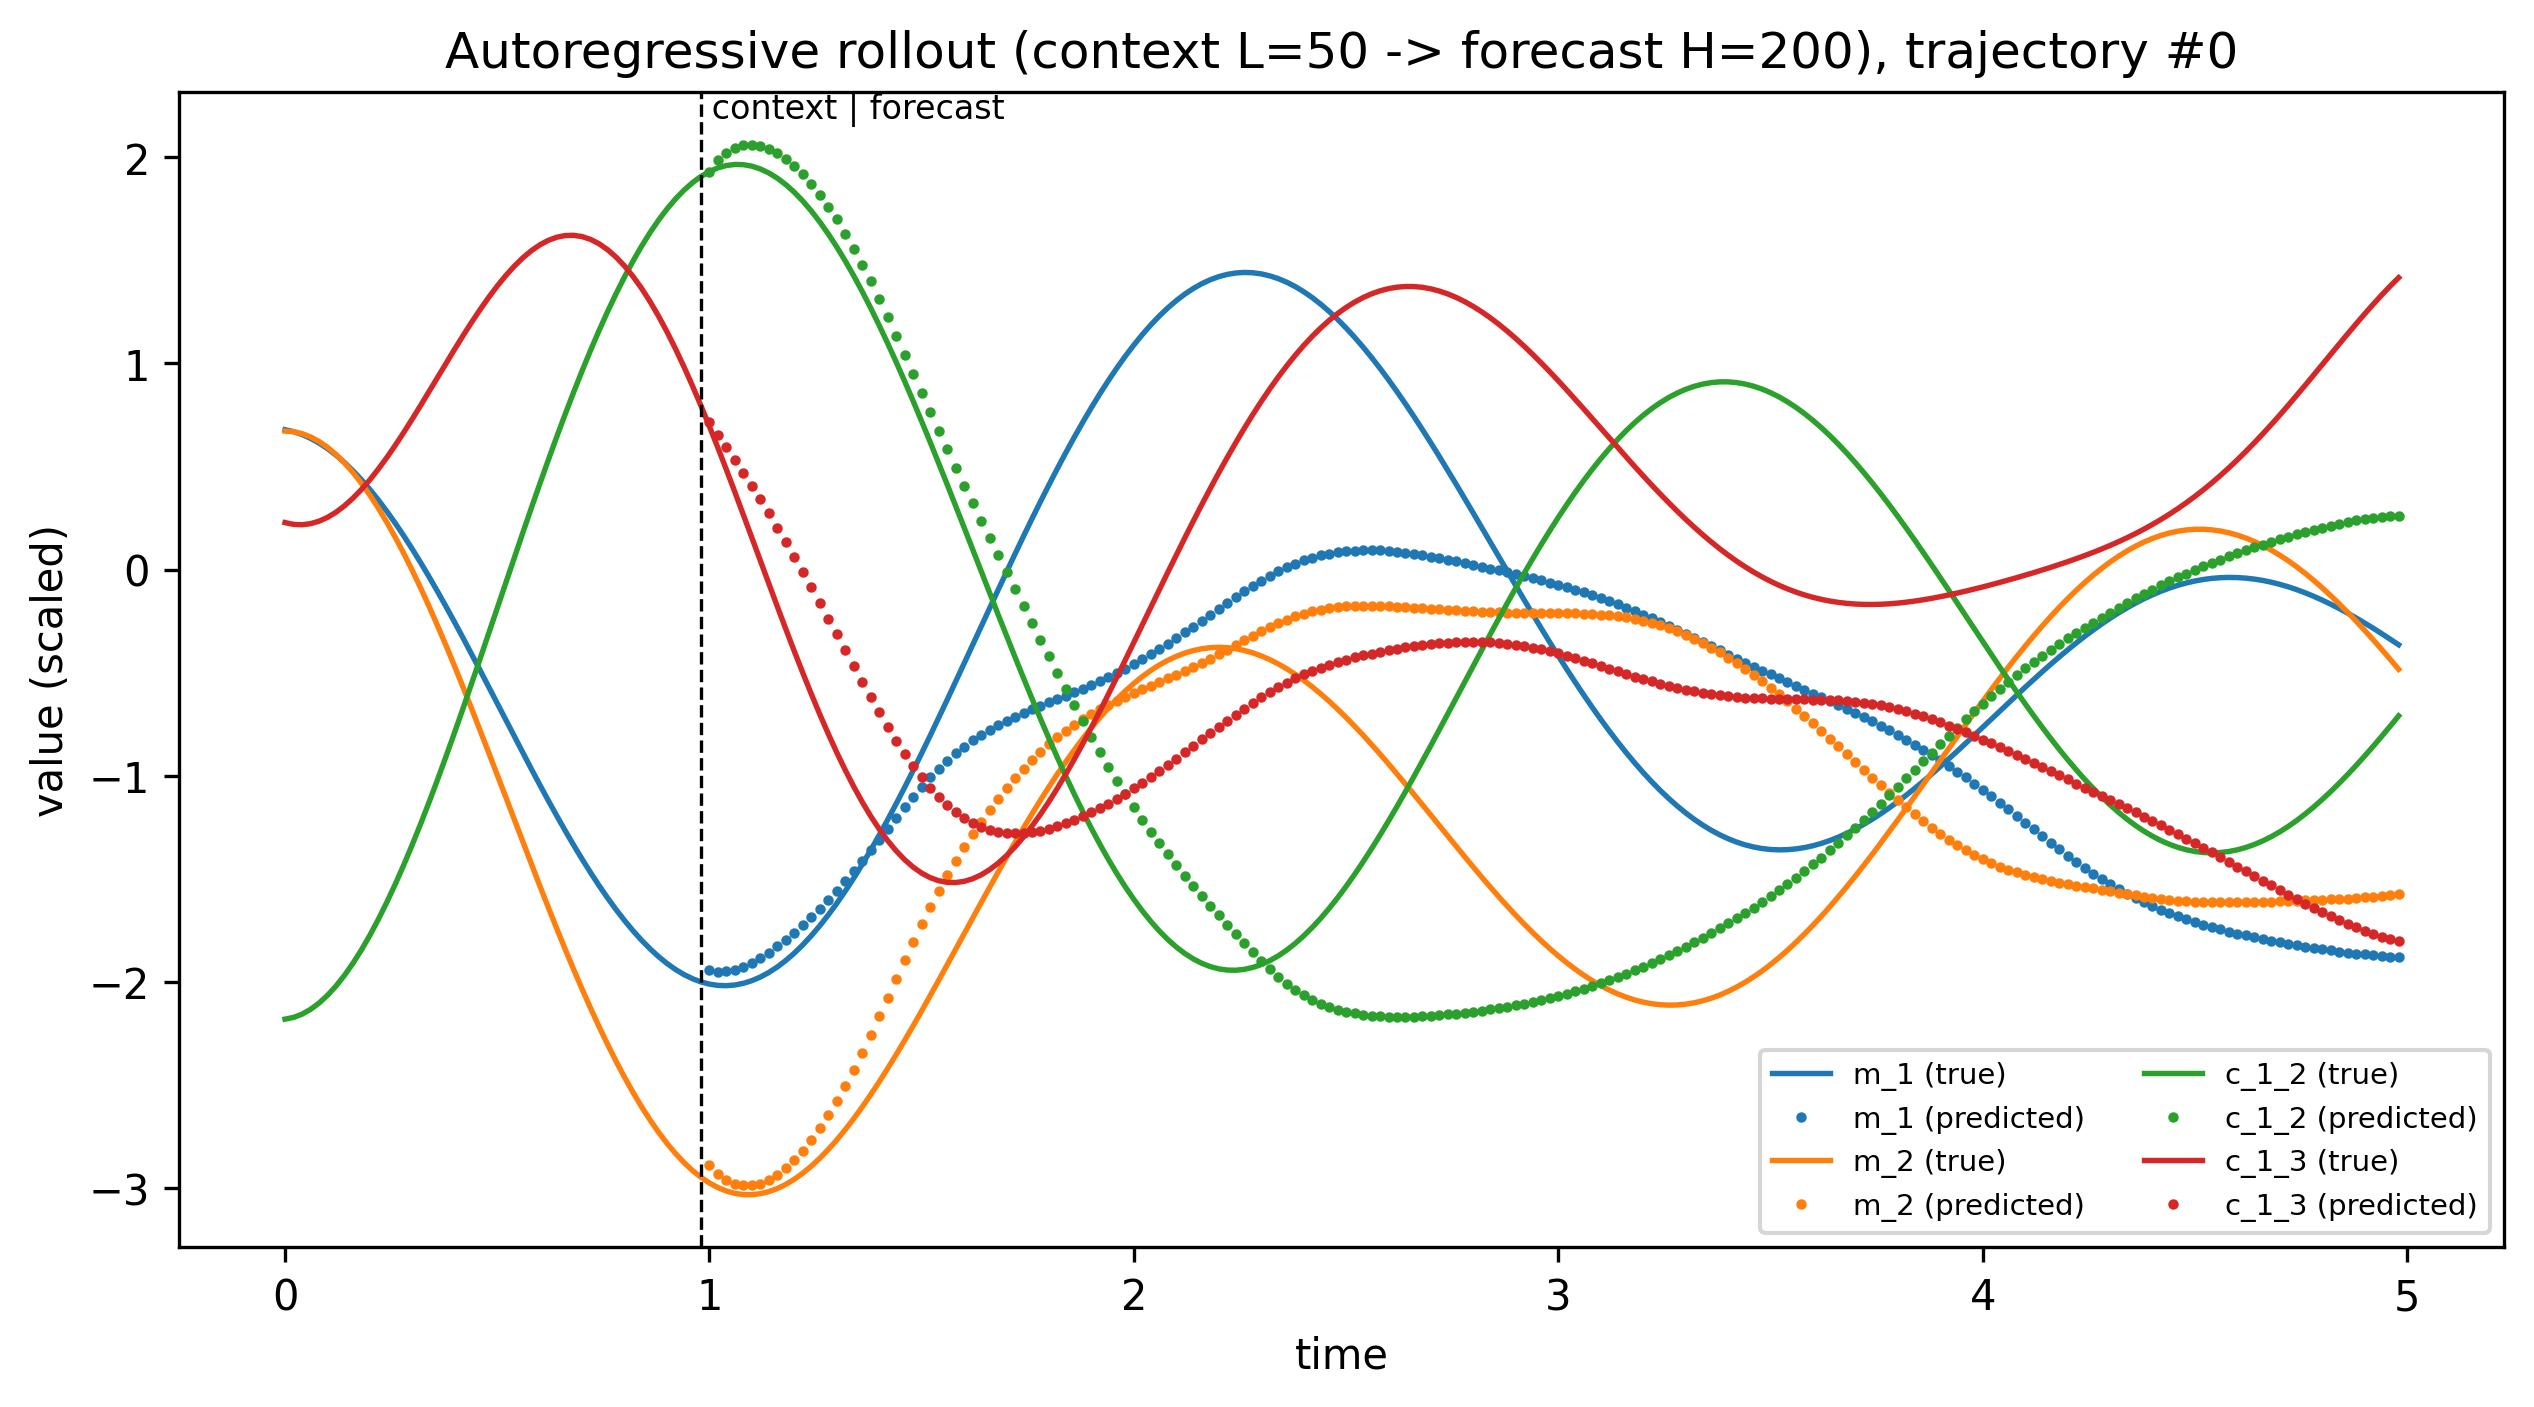

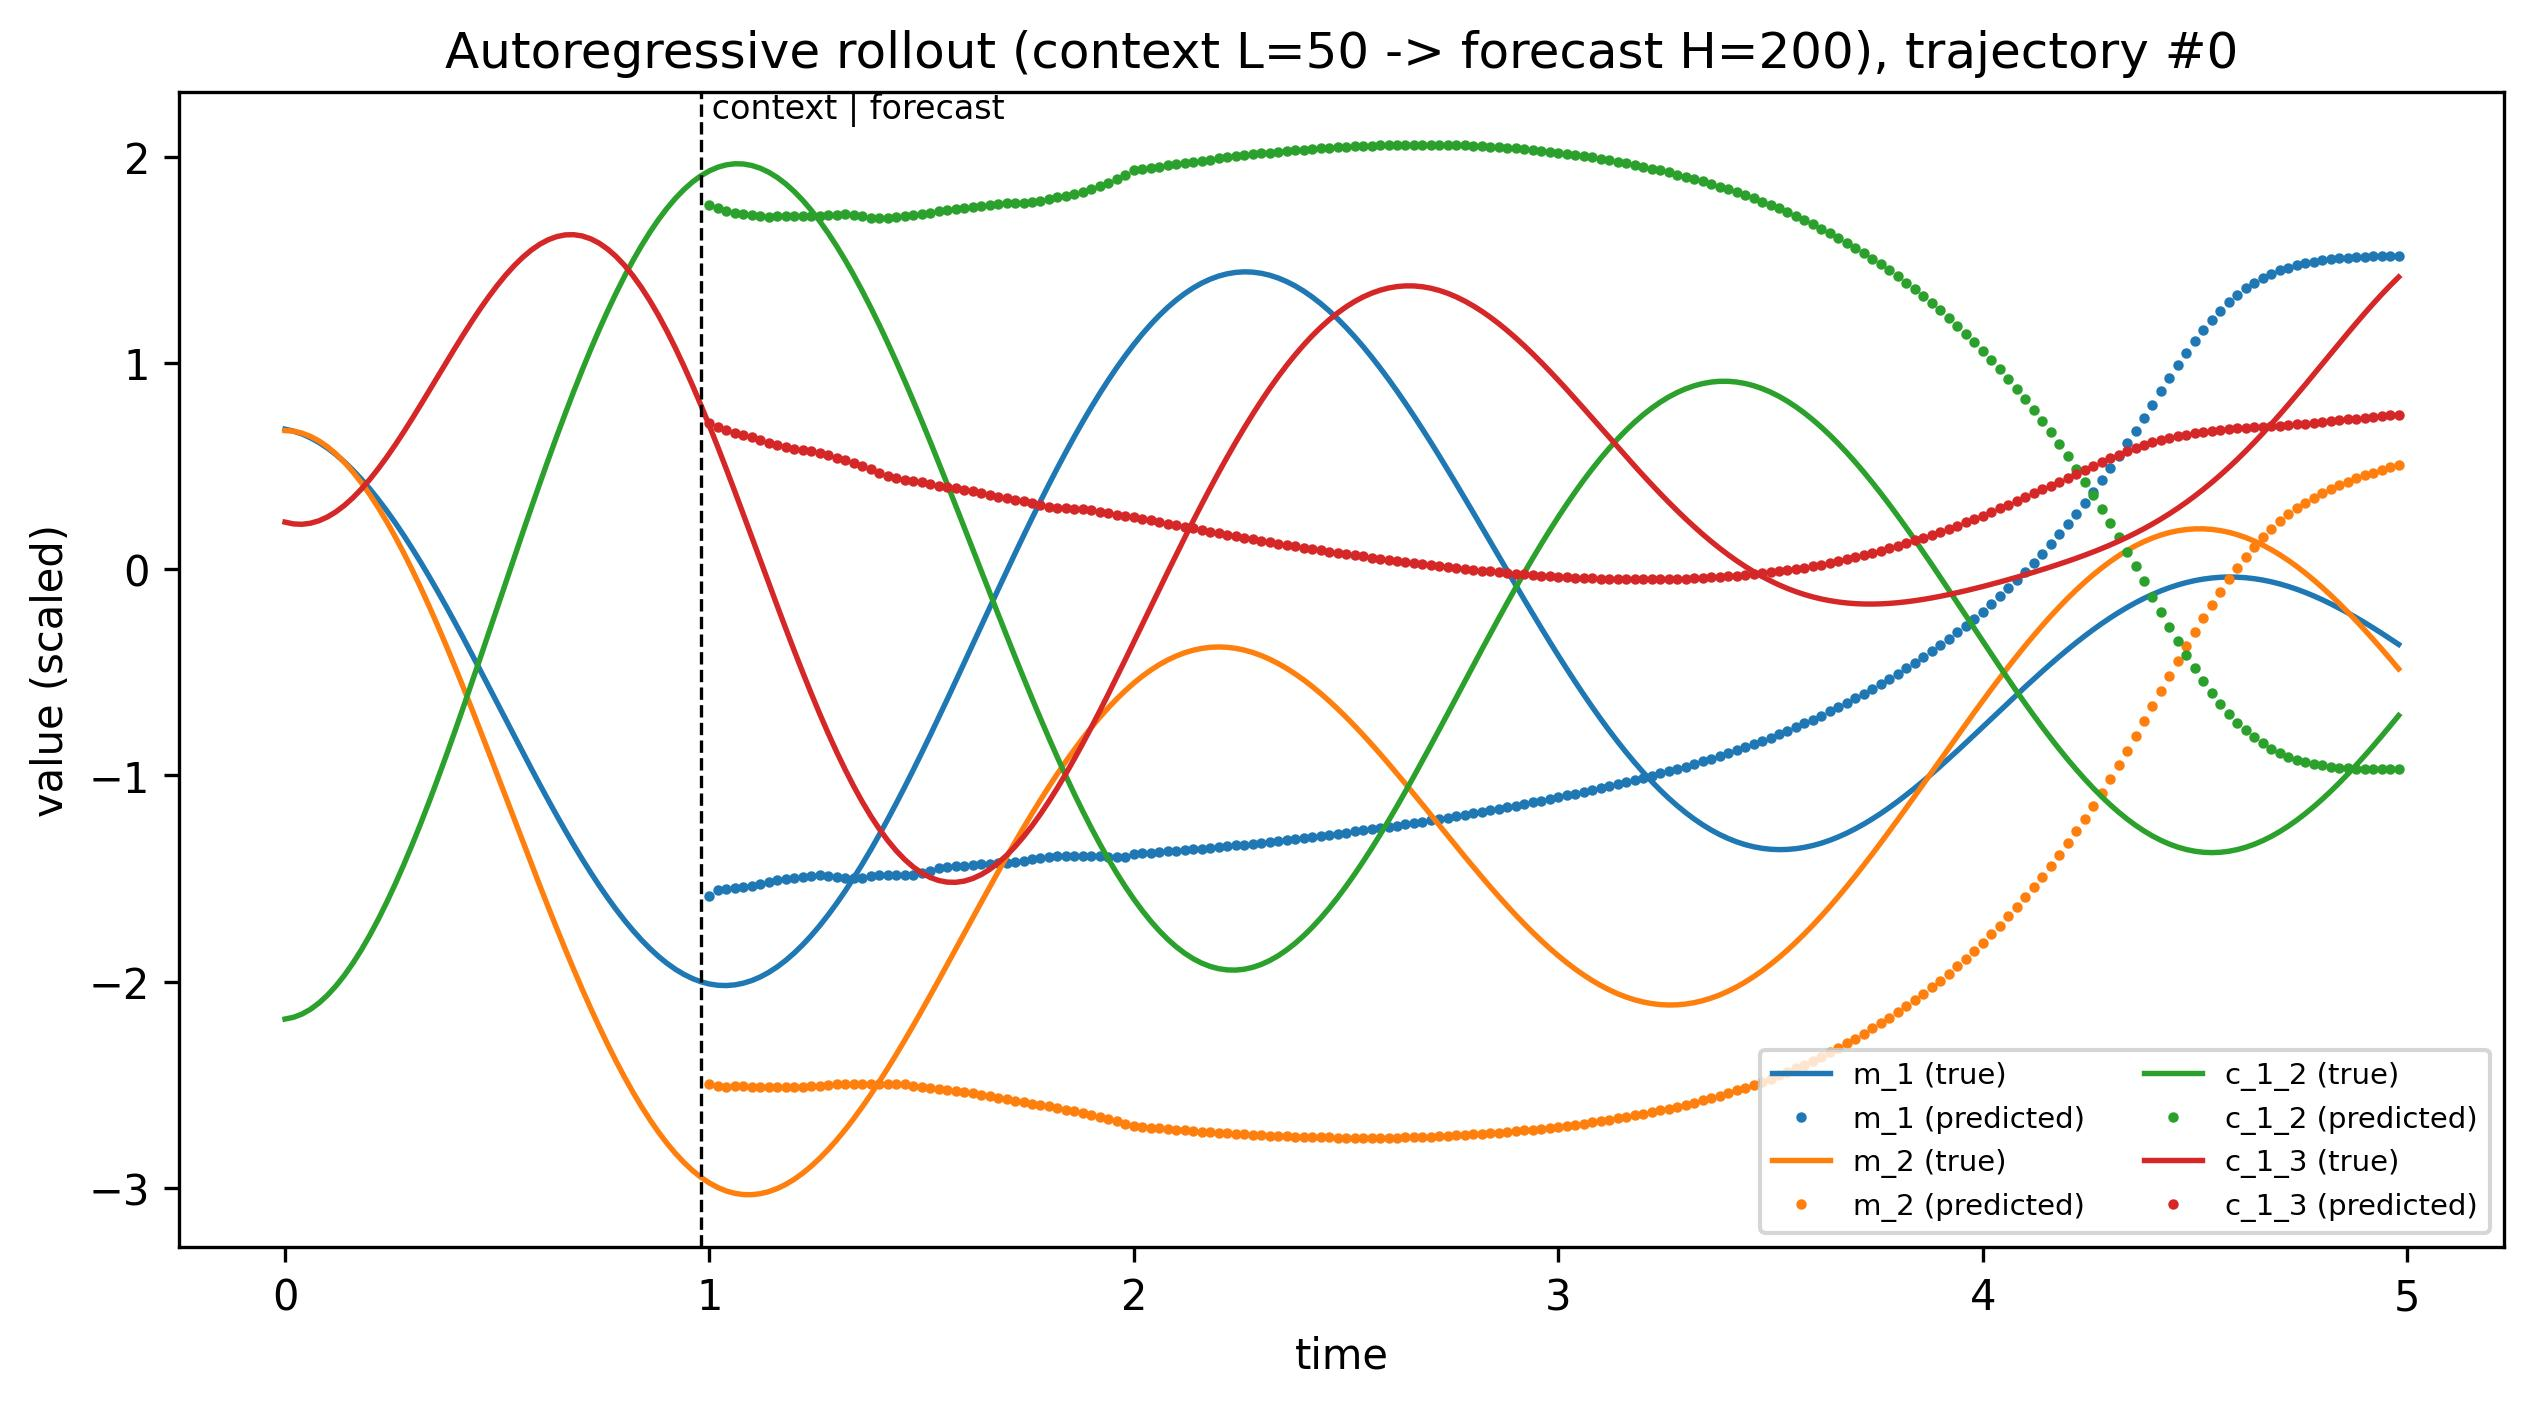

In [9]:
import os, sys, glob
import numpy as np

#Importo i moduli della pipeline
sys.path.insert(0, '/content/work/src')
os.chdir('/content/work/src')

from data_preprocessing import FeatureScaler, set_global_seeds
from models import load_model_bundle
from training import evaluate_nextstep, evaluate_rollout, arrays_to_dataset, plot_rollout
from baselines import evaluate_rollout_baselines

set_global_seeds(42)
WINDOW = 50
MODELS = '../artifacts/step3/models'

#Carico il pacchetto di test gia' preparato dallo Step 3 e ripristino lo scaler
#stimato sul training: nessuna statistica del test entra nella normalizzazione
_pk = f'{MODELS}/test_pack_L{WINDOW}.npz'
if not os.path.exists(_pk):
    _pk = f'{MODELS}/test_pack_L{WINDOW}_demo.npz'
pack = np.load(_pk, allow_pickle=True)
print(f"[inferenza] pacchetto usato: {os.path.basename(_pk)}")
scaler = FeatureScaler('per_feature_zscore')
scaler.mean_ = pack['scaler_mean'].astype('float32')
scaler.std_ = pack['scaler_std'].astype('float32')
X_test, Y_test = pack['X_test'], pack['Y_test']
ctx, fut = pack['ctx_test'], pack['fut_test']
names = [str(s) for s in pack['feature_names']]
NQ = int(pack['n_qubits']) if 'n_qubits' in pack.files else 10
ORIGIN = int(np.asarray(pack['origins']).ravel()[0]) if 'origins' in pack.files else 0
print(f"test: {len(pack['test_traj_ids'])} traiettorie | un passo {X_test.shape} | "
      f"rollout {ctx.shape} -> {fut.shape}")

#Calcolo prima le baseline: senza un riferimento che non impara nulla,l'errore dei modelli non e' interpretabile
bl = evaluate_rollout_baselines(ctx, fut, scaler=scaler,
                                feature_idx=pack['feature_idx'], n_qubits=NQ)
for n, m in sorted(bl.items(), key=lambda kv: kv[1]['rollout_rmse_physical']):
    print(f"  baseline {n:14s} rollout RMSE = {m['rollout_rmse_physical']:.5f}"
          f"   NRMSE = {m['rollout_nrmse']:.3f}")

#Per ogni modello selezionato: previsione a un passo, rollout autoregressivo,
#metriche in unita' fisiche e skill score rispetto alla migliore baseline
for spec in sorted(glob.glob(f'{MODELS}/best_*_L{WINDOW}_spec.json')):
    tag = os.path.basename(spec).replace('_spec.json', '')
    model = load_model_bundle(MODELS, tag)
    ns = evaluate_nextstep(model, arrays_to_dataset(X_test, Y_test, 64, shuffle=False),
                           scaler=scaler)
    ro = evaluate_rollout(model, ctx, fut, scaler=scaler,
                          feature_idx=pack['feature_idx'], n_qubits=NQ, baselines=bl)
    print(f"\n{tag}  ({model.count_params():,} parametri)")
    print(f"  RMSE a un passo (scalato) = {ns['rmse']:.4f}   MAE = {ns['mae']:.4f}")
    print(f"  RMSE di rollout (fisico)  = {ro['rollout_rmse_physical']:.5f}"
          f"   NRMSE = {ro['rollout_nrmse']:.3f}   skill = {ro['skill_vs_baseline']:+.3f}")

    plot_rollout(model, ctx, fut, pack['time_grid'], names,
                 f'{MODELS}/rollout_{tag}.jpg', origin=ORIGIN)

from IPython.display import Image, display

#Mostro i grafici appena generati
for p in sorted(glob.glob(f'{MODELS}/rollout_best_*.jpg')):
    display(Image(p, width=900))

## Cella 9 — Verifica della riproducibilità

Questa cella non esegue test unitari sui singoli moduli: riesegue l'intero sweep dello Step 3 in una cartella separata (`artifacts/repro_check`) e confronta le due esecuzioni con `tests/verify_reproducibility.py`. Il confronto avviene su tre livelli: tutte le metriche di `results_full.json`, la Tabella 1 carattere per carattere e i pesi salvati, confrontati per hash MD5.

È il controllo che serve per sostenere che i risultati riportati siano riproducibili: semi fissati per Python, NumPy e TensorFlow e determinismo delle operazioni abilitato dove la piattaforma lo consente. Va tenuto presente il costo: raddoppia il tempo dello Step 3, quindi ha senso lanciarla solo quando c'è tempo per un secondo sweep completo.

In [10]:
import subprocess, sys

#Rieseguo lo sweep dello Step 3 con gli stessi parametri, in una cartella separata,e confronto le due esecuzioni: metriche, tabelle e pesi dei modelli
#Con i seed fissati e il determinismo delle operazioni abilitato le due esecuzioni devono coincidere, pesi compresi
subprocess.run(['python3', 'src/run_step3_experiments.py', '--csv', 'trajectories.csv',
                '--out', 'artifacts/repro_check', '--windows', '50,100', '--folds', '5',
                '--schedule', '6,6,3', '--horizon', '200', '--origins', '0,250,500',
                '--ss-mode', 'true', '--ss-passes', '3'], cwd='/content/work')
subprocess.run([sys.executable, 'tests/verify_reproducibility.py',
                'artifacts/step3', 'artifacts/repro_check'], cwd='/content/work')

CompletedProcess(args=['/usr/bin/python3', 'tests/verify_reproducibility.py', 'artifacts/step3', 'artifacts/repro_check'], returncode=0)

### Cella 9-bis — Controllo sullo scheduled sampling

Lo scheduled sampling sostituisce parte degli ingressi con le previsioni del modello. Farlo alla lettera, un istante alla volta, richiederebbe un passaggio in avanti per ogni posizione della finestra; nel training loop la sostituzione è invece iterata a punto fisso, ed è esatta perché il modello è causale: dopo $K$ iterazioni le prime $K+1$ posizioni coincidono con la sostituzione sequenziale, e con $K=L-1$ coincide l'intera finestra. Il numero di iterazioni diventa così un iperparametro che scambia fedeltà con costo.

Il test verifica numericamente questa proprietà su tre modelli diversi e controlla anche che la variante a una sola iterazione produca un risultato effettivamente differente: senza quest'ultimo confronto il test passerebbe anche se le due modalità coincidessero per errore.

In [11]:
import subprocess, sys

#Verifica numerica della proprieta' a punto fisso dello scheduled sampling:
#l'iterazione usata nel training loop deve coincidere con la sostituzione sequenziale sulle prime K+1 posizioni,e la variante a una sola iterazione deve differirne
subprocess.run([sys.executable, 'tests/test_scheduled_sampling.py'], cwd='/content/work')

CompletedProcess(args=['/usr/bin/python3', 'tests/test_scheduled_sampling.py'], returncode=0)

## Cella 10 — Numeri del report

Genero un file con tutte le cifre citate: errori, intervalli di confidenza, skill score, esito dei confronti di significatività, risultati dell'ablation che serve a evitare che un numero scritto nel testo diverga da quello della tabella corrispondente. Lo stesso contenuto in forma leggibile si ottiene con `dump_report_numbers.py`.

Nella stessa cella viene eseguita l'analisi di degradazione del rollout (`analyze_phase_decay.py`), che misura se il modello perde ampiezza o fase e salva `phase_analysis.json`: sono le cifre citate nella discussione del risultato e riprese dalle slide.

I grafici del rollout non vengono prodotti qui: stanno nella Cella 5 per la run dimostrativa e nella Cella 8-bis per i modelli selezionati.

In [12]:
import subprocess, sys

#Genero le macro LaTeX con i numeri dei risultati, per non trascrivere a mano nel documento cifre che potrebbero divergere dalle tabelle
subprocess.run([sys.executable, 'make_report_macros.py',
                '--results', '../artifacts/step3/results_full.json',
                '--ablation', '../artifacts/step3/ablation_full.json',
                '--out', '../artifacts/step3/report_numbers.tex'],
               cwd='/content/work/src')

#Analisi della degradazione del rollout: distingue il collasso di ampiezza dalla perdita di fase e scrive phase_analysis.json
for w in (50, 100):
    subprocess.run([sys.executable, 'analyze_phase_decay.py',
                    '--models', '../artifacts/step3/models', '--window', str(w),
                    '--out', '../artifacts/step3/phase_analysis.json'],
                   cwd='/content/work/src')

#Anteprima delle macro generate
print(open('/content/work/artifacts/step3/report_numbers.tex').read()[:1200])

% ------------------------------------------------------------------
% Generated automatically from the result files -- do not edit by hand
% ------------------------------------------------------------------
\newcommand{\nFolds}{5}
\newcommand{\nOrigins}{3}
\newcommand{\originList}{0, 250, 500}
\newcommand{\nConfigRnn}{4}
\newcommand{\nConfigTr}{4}
\newcommand{\nWindows}{2}
\newcommand{\nRuns}{80}
\newcommand{\windowList}{$L=50$ and $L=100$}
\newcommand{\scheduleStr}{\ensuremath{6{+}6{+}3}}
\newcommand{\nEpochs}{15}
\newcommand{\ssPasses}{3}
\newcommand{\maskProb}{\ensuremath{0.15}}
\newcommand{\reproStatus}{enabled}
% ---- results for time window L=50 ----
\newcommand{\windowA}{50}
\newcommand{\blBestA}{train-mean}
\newcommand{\blBestRmseA}{\ensuremath{0.0279}}
\newcommand{\blBestNrmseA}{\ensuremath{0.597}}
\newcommand{\bestRnnA}{R2}
\newcommand{\cvRnnRmseA}{\ensuremath{0.0372}}
\newcommand{\cvRnnCiA}{\ensuremath{0.0006}}
\newcommand{\testRnnRmseA}{\ensuremath{0.0376}}
\newcommand{\t

## Cella 11 — Esportazione dei risultati

Comprimo la cartella degli artefatti — figure a 300 dpi, tabelle CSV e LaTeX, JSON con i risultati per fold, pesi dei modelli selezionati — ed eseguo il download. Restano fuori dall'archivio la cache dei tensori (`artifacts/cache/`, centinaia di MB di `.npz` rigenerabili dallo Step 1 in pochi minuti), l'eventuale duplicato dello sweep creato dalla verifica di riproducibilità e i file temporanei dell'ambiente.

In [13]:
import os, zipfile
os.chdir('/content/work')
zpath = 'artifacts_DL_Quantum.zip'

#Comprimo figure, tabelle, risultati per fold e pesi dei modelli selezionati
#Escludo la cache dei tensori (centinaia di MB di .npz rigenerabili dallo Step 1), l'eventuale duplicato dello sweep creato dalla verifica di riproducibilita'
#e i file temporanei dell'ambiente
ESCLUSI = ('artifacts/cache', 'artifacts/repro_check')
n = 0
with zipfile.ZipFile(zpath, 'w', zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk('artifacts'):
        dirs[:] = [d for d in dirs
                   if not os.path.join(root, d).startswith(ESCLUSI) and d != '__pycache__']
        for f in files:
            if f == '.DS_Store':
                continue
            z.write(os.path.join(root, f))
            n += 1

print(f"{zpath}  ({os.path.getsize(zpath)/1024**2:.1f} MB, {n} file)")

#Download del pacchetto sulla macchina locale
try:
    from google.colab import files
    files.download(zpath)
except Exception as e:
    print('Scarica il file dalla sidebar di Colab.', e)

artifacts_DL_Quantum.zip  (69.9 MB, 46 file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusioni

**Sul rollout lungo i modelli non battono i predittori banali.** Lo skill score resta negativo su entrambe le finestre e per entrambe le architetture: sull'intero orizzonte la migliore baseline ha un errore inferiore. Il risultato ci dice quale sia il predittore difficile da battere: su un orizzonte lungo la dinamica si discosta dal contesto e la media costante diventa la scelta che minimizza l'errore quadratico.

**Il confronto sensato è per orizzonte, non aggregato.** La metrica aggregata mescola due regimi che la curva dell'errore in funzione del passo previsto tiene separati. Rispetto alla baseline banale più forte per ciascuna finestra (train-mean a $L=50$, context-mean a $L=100$), il modello appreso ha errore inferiore in una finestra iniziale dell'orizzonte — passi 1–25 (RNN) e 1–22 (Transformer) a $L=50$, 1–30 per entrambe le architetture a $L=100$ — dopodiché la baseline resta sotto per il resto dei 200 passi, ed è questo secondo regime, molto più lungo, a dominare l'RMSE aggregato. Nei primissimi passi, invece, nessuno dei due modelli batte il predittore locale *drift*: con $\Delta t = 0.02$ lo stato cambia pochissimo fra istanti vicini e l'estrapolazione lineare a due punti è 23–45 volte più accurata sul passo singolo, ma il suo errore cresce così in fretta nel rollout che il vantaggio resta confinato a quei primi passi.

**L'exposure bias si misura.** Il rapporto fra l'errore all'ultimo passo e quello al primo è il numero che quantifica l'accumulo, ed è sistematicamente più contenuto per il Transformer che per la RNN: l'attenzione causale mantiene accesso diretto a tutta la finestra di contesto, mentre la ricorrenza deve farla passare attraverso lo stato nascosto, che il rollout riempie progressivamente di valori predetti.

**Le differenze fra configurazioni sono in gran parte dentro gli intervalli di confidenza.** Per questo la selezione è a due stadi: si ordina per errore medio di rollout e, fra le configurazioni con intervalli sovrapposti, si sceglie quella con il migliore errore a un passo. La configurazione selezionata può quindi non essere quella con la media migliore in tabella.

**L'ablation sostiene l'inclusione dei regimi, non il loro ordine.** Tutte le varianti spendono lo stesso budget di epoche. Dove gli intervalli sono disgiunti la differenza è reale; dove si sovrappongono l'unica osservazione è che i dati non distinguono le due varianti.

**Il confronto fra le due finestre non è a parità di problema.** Le coppie di rollout partono da $t_0+L$, quindi con $L=100$ gli istanti da prevedere cadono cinquanta passi più avanti, su un tratto di dinamica diverso e non necessariamente altrettanto difficile. Il segno del confronto è coerente su tutte le configurazioni, ma va letto insieme al comportamento delle baseline sulle stesse coppie: se migliorano anche loro, il guadagno non è del modello.
